In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import tensorflow as tf
import torch


In [38]:
import os
import PIL
from PIL import Image
import tensorflow as tf
import tensorflow_datasets as tfds
import pathlib
from collections import Counter
from torchvision import transforms
import torchvision.transforms as T
from torch.utils.data import Dataset

In [ ]:
print(tf.__version__)

2.16.2


In [23]:
base_dir = pathlib.Path("data/classification-of-pet-facial-expression")
train_dir = base_dir / "train" / "train"
test_dir  = base_dir / "test" / "test"

train_paths = sorted(train_dir.glob("*/*.jpg"))   # Angry/Happy/Sad
test_paths  = sorted(test_dir.glob("*.jpg"))      # unlabeled test images

print("train:", len(train_paths), "test:", len(test_paths))


train: 450 test: 300


In [29]:
classes = sorted(set((p.parent.name for p in train_paths)))
ctoi = {c: i for i,c in enumerate(classes)}
itoc = {i: c for c,i in ctoi.items()}
print("classes:", classes)

classes: ['Angry', 'Happy', 'Sad']


In [32]:
sizes = []
modes = Counter()

for p in train_paths[:500]:  # sample (or remove slice for full)
    with Image.open(p) as im:
        sizes.append(im.size)   # (W,H)
        modes[im.mode] += 1

ws = [w for w, h in sizes]
hs = [h for w, h in sizes]
print("mode counts:", modes)
print("width min/med/max:", min(ws), sorted(ws)[len(ws)//2], max(ws))
print("height min/med/max:", min(hs), sorted(hs)[len(hs)//2], max(hs))

mode counts: Counter({'RGB': 450})
width min/med/max: 179 224 224
height min/med/max: 179 224 224


In [36]:
img_size = 224
train_tfms = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),  
])
test_tfms = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
])

In [ ]:
class PetExpressionTrain(Dataset):
    def __init__(self, paths, ctoi, transform=None):
        self.paths = paths
        self.ctoi = ctoi
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        y = self.ctoi[path.parent.name]
        img = Image.open(path)
        if self.transform:
            img = self.transform(img)
        return img, y
class PetExpressionTest(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        path = self.paths[i]
        img = Image.open(path)
        if self.transform:
            img = self.transform(img)
        return img, path.name 

tensor: torch.Size([3, 224, 224]) torch.float32 min/max: 0.07058823853731155 0.9019607901573181 label: 0


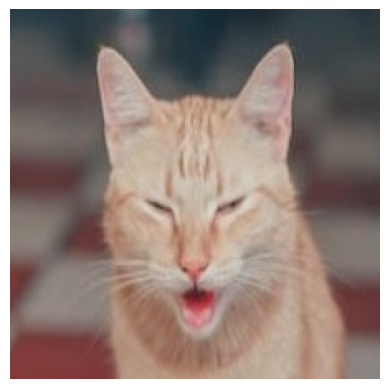

torch.Size([3, 224, 224])


In [ ]:
train_ds = PetExpressionTrain(train_paths, ctoi, transform=train_tfms)

x, y = train_ds[0]  
print("tensor:", x.shape, x.dtype, "min/max:", x.min().item(), x.max().item(), "label:", y)

to_pil = T.ToPILImage()
img_rec = to_pil(x)

plt.imshow(img_rec)
plt.axis("off")
plt.show()
print(x.shape)

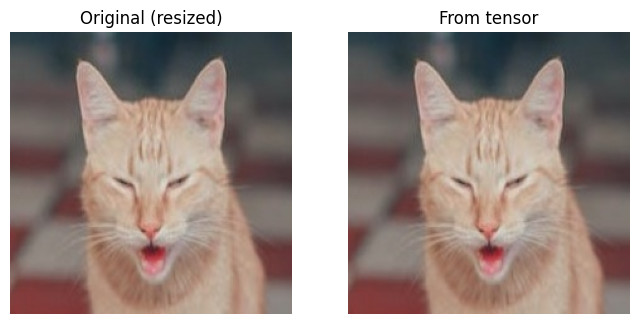

In [ ]:
path0 = train_paths[0]
orig = Image.open(path0)
orig_resized = T.Resize((224, 224))(orig)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(orig_resized); plt.title("Original (resized)"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_rec);      plt.title("From tensor");        plt.axis("off")
plt.show()